In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve, auc
from sklearn.calibration import calibration_curve
import shap


/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

df = pd.read_excel("stats output/final_merged_sv_targets.xlsx")

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())


Shape: (21225, 48)
   SUBJECT_ID  HADM_ID  VISIT_ID         MONITORTIME  SV1_min  SV1_max  \
0           4   102191         1 1981-09-25 18:40:00     67.0     95.0   
1           4   102191         1 1981-09-25 19:45:00     73.0     92.0   
2           4   102191         1 1981-09-25 20:50:00     70.0    116.0   
3           4   102191         1 1981-09-25 21:55:00     83.0     95.0   
4          37   102040         1 2071-08-12 11:00:00     70.0     99.0   

    SV1_mean  SV1_median  SV2_min  SV2_max  ...     LOS  LONG_ICU_STAY  \
0  77.461538        74.0     68.0     97.0  ...  0.5215              0   
1  80.846154        82.0     74.0     92.0  ...  0.5215              0   
2  91.461538        86.0     10.0     99.0  ...  0.5215              0   
3  88.000000        86.0     83.0     99.0  ...  0.5215              0   
4  84.928571        84.0     71.0    100.0  ...  0.7535              0   

   PAIN_SCORE  HIGH_PAIN                HOUR    HB_MEAN  HB_MIN  HB_MAX  \
0         NaN   

In [4]:

# --------------------------------------------------
# Step 2: Basic cleanup
# --------------------------------------------------
df.columns = [c.strip() for c in df.columns]

# Target column
target_col = "HOSPITAL_EXPIRE_FLAG"

# Ensure target is numeric
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

# Drop rows where target is missing
df = df.dropna(subset=[target_col]).copy()

# Convert target to int
df[target_col] = df[target_col].astype(int)


In [5]:

# --------------------------------------------------
# Step 3: Create / clean ICD diagnosis feature
# --------------------------------------------------
# Prefer ICD_CATEGORY if already present
if "ICD_CATEGORY" not in df.columns:
    if "ICD10_CODE_CN" in df.columns:
        df["ICD_CATEGORY"] = df["ICD10_CODE_CN"].astype(str).str[0]
        df.loc[df["ICD10_CODE_CN"].isna(), "ICD_CATEGORY"] = np.nan
    else:
        df["ICD_CATEGORY"] = np.nan

# Clean ICD_CATEGORY a bit
df["ICD_CATEGORY"] = df["ICD_CATEGORY"].replace(
    ["nan", "None", "NAN", ""], np.nan
)


In [6]:

# --------------------------------------------------
# Step 4: Define candidate feature columns
# --------------------------------------------------
# Numeric features from your engineered dataset
candidate_numeric_features = [
    # SV means
    "SV1_mean", "SV2_mean", "SV3_mean", "SV4_mean", "SV5_mean", "SV6_mean", "SV7_mean",

    # SV min
    "SV1_min", "SV2_min", "SV3_min", "SV4_min", "SV5_min", "SV6_min", "SV7_min",

    # SV max
    "SV1_max", "SV2_max", "SV3_max", "SV4_max", "SV5_max", "SV6_max", "SV7_max",

    # SV median
    "SV1_median", "SV2_median", "SV3_median", "SV4_median", "SV5_median", "SV6_median", "SV7_median",

    # Hemoglobin / pain / engineered flags
    "HB_MEAN", "HB_MIN", "HB_MAX",
    "PAIN_SCORE", "HIGH_PAIN",
    "ANEMIA_FLAG", "SEVERE_ANEMIA"
]

# Add SV range features if not already present but min/max exist
for i in range(1, 8):
    range_col = f"SV{i}_range"
    min_col = f"SV{i}_min"
    max_col = f"SV{i}_max"

    if range_col not in df.columns and min_col in df.columns and max_col in df.columns:
        df[range_col] = df[max_col] - df[min_col]

# Append range columns
candidate_numeric_features += [f"SV{i}_range" for i in range(1, 8)]

# Keep only columns that actually exist
numeric_features = [c for c in candidate_numeric_features if c in df.columns]

# Categorical feature
categorical_features = []
if "ICD_CATEGORY" in df.columns:
    categorical_features.append("ICD_CATEGORY")

# --------------------------------------------------
# Step 5: Exclude leakage / outcome-related columns
# --------------------------------------------------
# Do NOT include LOS / LONG_ICU_STAY in mortality model
leakage_cols = [
    "LOS",
    "LONG_ICU_STAY",
    "HOSPITAL_EXPIRE_FLAG"
]

numeric_features = [c for c in numeric_features if c not in leakage_cols]

print("\nNumeric features used:")
print(numeric_features)

print("\nCategorical features used:")
print(categorical_features)



Numeric features used:
['SV1_mean', 'SV2_mean', 'SV3_mean', 'SV4_mean', 'SV5_mean', 'SV6_mean', 'SV7_mean', 'SV1_min', 'SV2_min', 'SV3_min', 'SV4_min', 'SV5_min', 'SV6_min', 'SV7_min', 'SV1_max', 'SV2_max', 'SV3_max', 'SV4_max', 'SV5_max', 'SV6_max', 'SV7_max', 'SV1_median', 'SV2_median', 'SV3_median', 'SV4_median', 'SV5_median', 'SV6_median', 'SV7_median', 'HB_MEAN', 'HB_MIN', 'HB_MAX', 'PAIN_SCORE', 'HIGH_PAIN', 'ANEMIA_FLAG', 'SEVERE_ANEMIA', 'SV1_range', 'SV2_range', 'SV3_range', 'SV4_range', 'SV5_range', 'SV6_range', 'SV7_range']

Categorical features used:
['ICD_CATEGORY']


In [7]:

# --------------------------------------------------
# Step 6: Build X and y
# --------------------------------------------------
feature_cols = numeric_features + categorical_features

X = df[feature_cols].copy()
y = df[target_col].copy()

print("\nX shape:", X.shape)
print("y distribution:")
print(y.value_counts(dropna=False))

# --------------------------------------------------
# Step 7: Train-test split
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)



X shape: (21225, 43)
y distribution:
HOSPITAL_EXPIRE_FLAG
0    20731
1      494
Name: count, dtype: int64

Train shape: (16980, 43)
Test shape: (4245, 43)


In [8]:

# --------------------------------------------------
# Step 8: Preprocessing
# --------------------------------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)


In [9]:

# --------------------------------------------------
# Step 9: Logistic Regression model
# --------------------------------------------------
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Logistic Regression Results")
print("==============================")
print(classification_report(y_test, y_pred_lr,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))



Logistic Regression Results
              precision    recall  f1-score   support

           0     0.9931    0.7672    0.8657      4146
           1     0.0739    0.7778    0.1350        99

    accuracy                         0.7675      4245
   macro avg     0.5335    0.7725    0.5003      4245
weighted avg     0.9717    0.7675    0.8487      4245

Confusion Matrix:
[[3181  965]
 [  22   77]]
ROC-AUC: 0.8411783049988549
Accuracy: 0.7674911660777385


In [11]:

# --------------------------------------------------
# Step 10: Hyperparameter tuning for Logistic Regression
# --------------------------------------------------
param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"],
    "model__penalty": ["l2"]
}

grid_lr = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=param_grid_lr,
    cv=3,
    scoring="f1",
    n_jobs=1
)

grid_lr.fit(X_train, y_train)

print("\n")
print("Best Logistic Regression Parameters")
print("------------")
print(grid_lr.best_params_)

best_lr = grid_lr.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test)
y_prob_lr_tuned = best_lr.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Tuned Logistic Regression Results")
print("==============================")
print(classification_report(y_test, y_pred_lr_tuned,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))



Best Logistic Regression Parameters
------------
{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Tuned Logistic Regression Results
              precision    recall  f1-score   support

           0     0.9931    0.7672    0.8657      4146
           1     0.0739    0.7778    0.1350        99

    accuracy                         0.7675      4245
   macro avg     0.5335    0.7725    0.5003      4245
weighted avg     0.9717    0.7675    0.8487      4245

Confusion Matrix:
[[3181  965]
 [  22   77]]
ROC-AUC: 0.8415437539894849
Accuracy: 0.7674911660777385


In [12]:

# --------------------------------------------------
# Step 10: Random Forest model
# --------------------------------------------------
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Random Forest Results")
print("==============================")
print(classification_report(y_test, y_pred_rf,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))



Random Forest Results
              precision    recall  f1-score   support

           0     0.9767    1.0000    0.9882      4146
           1     0.0000    0.0000    0.0000        99

    accuracy                         0.9767      4245
   macro avg     0.4883    0.5000    0.4941      4245
weighted avg     0.9539    0.9767    0.9652      4245

Confusion Matrix:
[[4146    0]
 [  99    0]]
ROC-AUC: 0.8644452240689579
Accuracy: 0.976678445229682


/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=3,
    scoring="f1",
    n_jobs=1
)

grid_rf.fit(X_train, y_train)

print("\n")
print("Best Random Forest Parameters")
print("---------")
print(grid_rf.best_params_)

best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("\n")
print("Tuned Random Forest Results")
print("---------")
print(classification_report(y_test, y_pred_rf_tuned,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))



Best Random Forest Parameters
---------
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}


Tuned Random Forest Results
---------
              precision    recall  f1-score   support

           0     0.9823    0.9522    0.9671      4146
           1     0.1239    0.2828    0.1723        99

    accuracy                         0.9366      4245
   macro avg     0.5531    0.6175    0.5697      4245
weighted avg     0.9623    0.9366    0.9485      4245

Confusion Matrix:
[[3948  198]
 [  71   28]]
ROC-AUC: 0.8401428661920703
Accuracy: 0.9366313309776207


<Figure size 700x500 with 0 Axes>

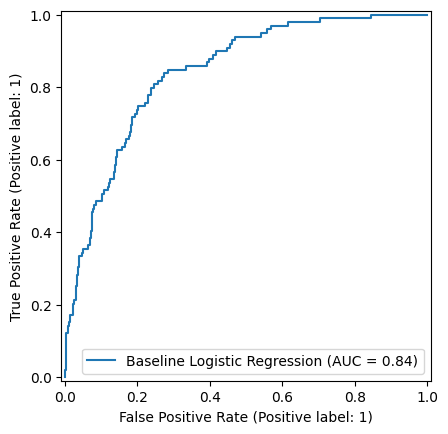

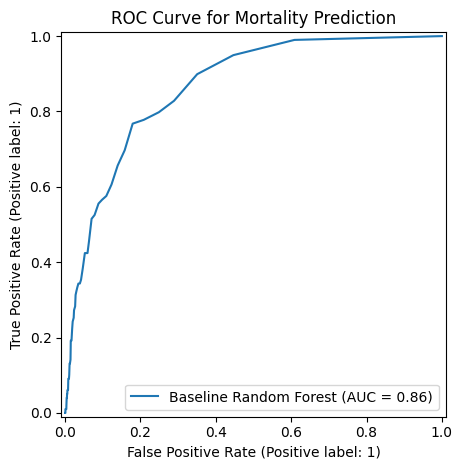

In [64]:

# --------------------------------------------------
# Step 11: ROC Curves (baseline models)
# --------------------------------------------------
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Baseline Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Baseline Random Forest")

plt.title("ROC Curve for Mortality Prediction")
plt.tight_layout()
plt.show()


<Figure size 700x500 with 0 Axes>

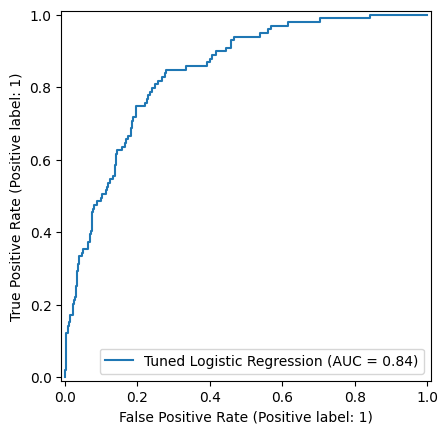

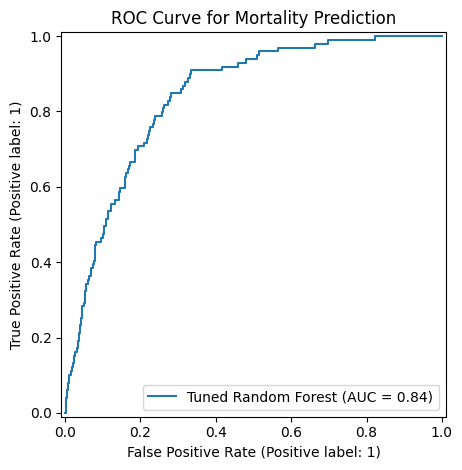

In [65]:

# --------------------------------------------------
# Step 11: ROC Curves (tune models)
# --------------------------------------------------
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_lr_tuned, name="Tuned Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf_tuned, name="Tuned Random Forest")

plt.title("ROC Curve for Mortality Prediction")
plt.tight_layout()
plt.show()



Top 15 Important Features:
                             feature  importance
6                      num__SV7_mean    0.062044
2                      num__SV3_mean    0.057876
27                   num__SV7_median    0.056150
23                   num__SV3_median    0.053443
16                      num__SV3_max    0.042942
9                       num__SV3_min    0.041736
0                      num__SV1_mean    0.035714
55  cat__ICD_CATEGORY_Nervous system    0.032902
13                      num__SV7_min    0.030463
3                      num__SV4_mean    0.029355
21                   num__SV1_median    0.028987
24                   num__SV4_median    0.028223
8                       num__SV2_min    0.028149
5                      num__SV6_mean    0.025698
14                      num__SV1_max    0.025661


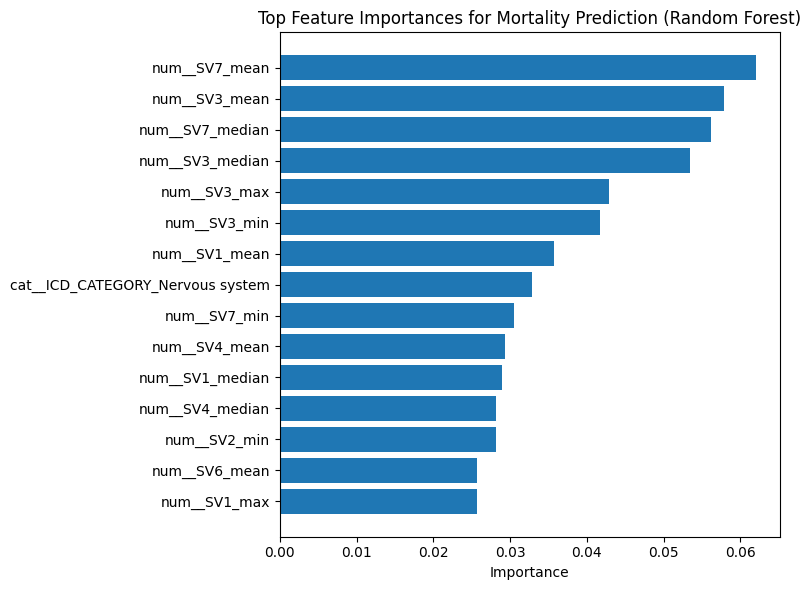

In [61]:

# --------------------------------------------------
# Step 12: Random Forest feature importance
# --------------------------------------------------
# Extract fitted preprocessing and model
fitted_preprocessor = best_rf.named_steps["preprocessor"]
fitted_model = best_rf.named_steps["model"]

# Get expanded feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Feature importances
importances = fitted_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 15 Important Features:")
print(importance_df.head(15))

# Plot top 15
top_n = 15
top_importance = importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("Top Feature Importances for Mortality Prediction (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [43]:
importance_df[importance_df["feature"].str.contains("ICD|PAIN|ANEMIA", case=False, na=False)]

,feature,importance
55,cat__ICD_CATEGORY_Nervous system,2.622775e-02
45,cat__ICD_CATEGORY_Digestive,1.302500e-02
44,cat__ICD_CATEGORY_Congenital,1.027259e-02
57,cat__ICD_CATEGORY_Perinatal,7.099801e-03
56,cat__ICD_CATEGORY_Other,4.605248e-03
51,cat__ICD_CATEGORY_Injury,4.507082e-03
43,cat__ICD_CATEGORY_Circulatory,3.692261e-03
58,cat__ICD_CATEGORY_Respiratory,3.632244e-03
60,cat__ICD_CATEGORY_Symptoms,3.129410e-03
42,cat__ICD_CATEGORY_Blood/Immune,2.207327e-03


In [ ]:

# --------------------------------------------------
# Step 13: Save model-ready predictions (optional)
# --------------------------------------------------
results_df = X_test.copy()
results_df["actual"] = y_test.values
results_df["pred_lr"] = y_pred_lr
results_df["prob_lr"] = y_prob_lr
results_df["pred_rf"] = y_pred_rf
results_df["prob_rf"] = y_prob_rf

results_df.to_csv("model_output/mortality_prediction_results.csv", index=False)
importance_df.to_csv("model_output/mortality_feature_importance.csv", index=False)


Model Reliability & Interpretability Analysis

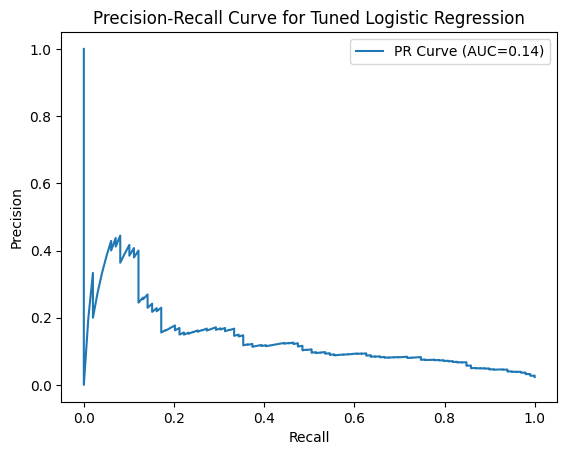

In [19]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_lr_tuned)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AUC={pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Tuned Logistic Regression")
plt.legend()
plt.show()

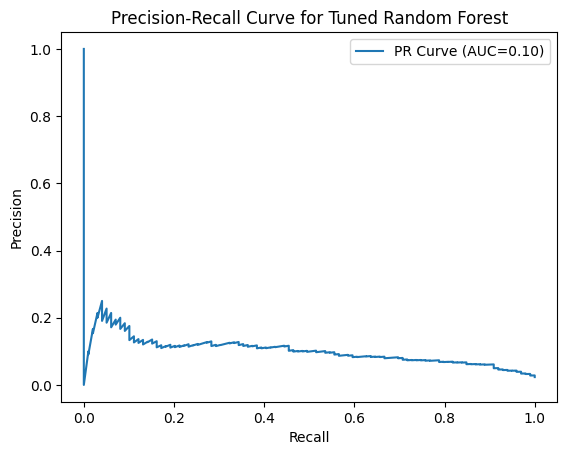

In [20]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf_tuned)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AUC={pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Tuned Random Forest")
plt.legend()
plt.show()

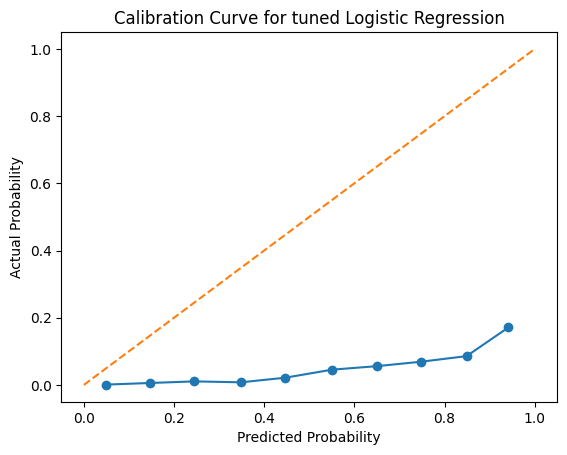

In [24]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_lr_tuned, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve for tuned Logistic Regression")
plt.show()

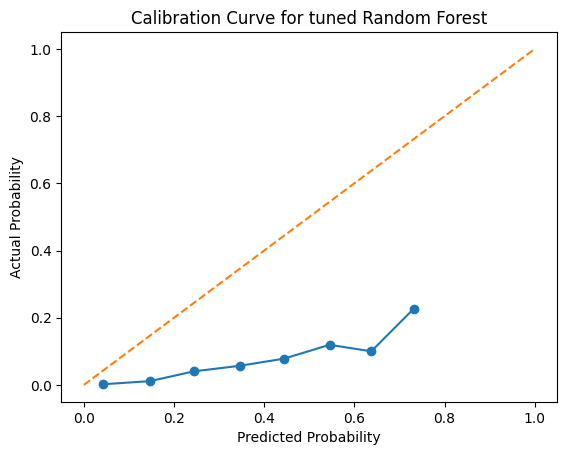

In [23]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_rf_tuned, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve for tuned Random Forest")
plt.show()

In [28]:

def run_shap_analysis(model_pipeline, X_test, model_name, max_display=15, sample_size=500):

    # Extract components
    preprocessor = model_pipeline.named_steps["preprocessor"]
    model = model_pipeline.named_steps["model"]

    # Transform test data
    X_transformed = preprocessor.transform(X_test)

    if hasattr(X_transformed, "toarray"):
        X_transformed = X_transformed.toarray()

    feature_names = preprocessor.get_feature_names_out()

    X_df = pd.DataFrame(
        X_transformed,
        columns=feature_names
    )

    # Sample for speed
    X_sample = X_df.sample(
        n=min(sample_size, len(X_df)),
        random_state=42
    )

    # Random Forest SHAP
    if "RandomForest" in str(type(model)):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)

        # Correct class-1 extraction
        if isinstance(shap_values, list):
            shap_values_plot = shap_values[1]
        elif len(np.array(shap_values).shape) == 3:
            shap_values_plot = shap_values[:, :, 1]
        else:
            shap_values_plot = shap_values

    # Logistic Regression SHAP
    else:
        explainer = shap.LinearExplainer(model, X_sample)
        shap_values_plot = explainer.shap_values(X_sample)

    # Summary plot
    shap.summary_plot(
        shap_values_plot,
        X_sample,
        max_display=max_display,
        show=False
    )

    plt.title(f"SHAP Summary Plot - {model_name}")
    plt.tight_layout()

    plt.show()



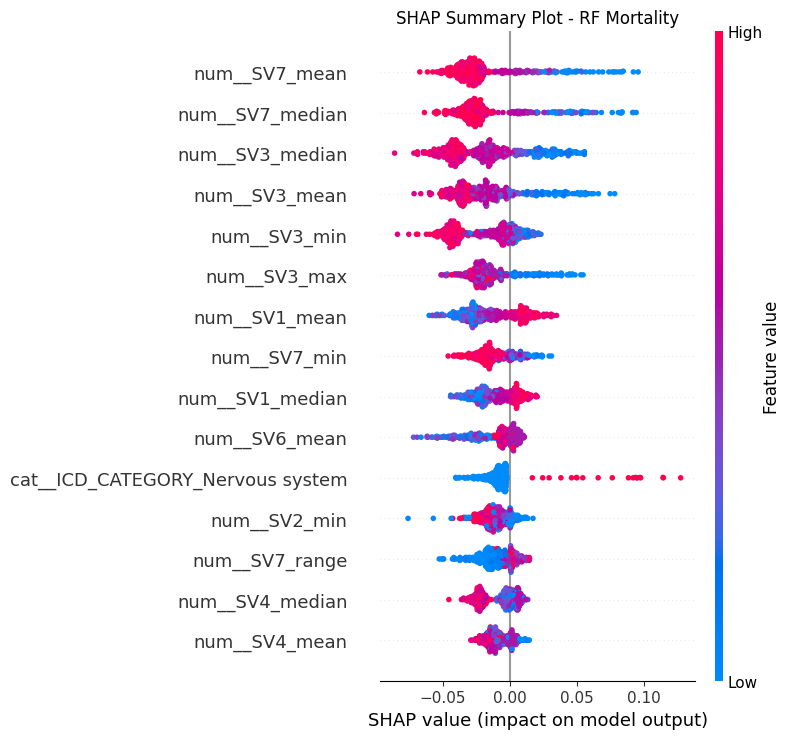

In [29]:
run_shap_analysis(best_rf, X_test, "RF Mortality")


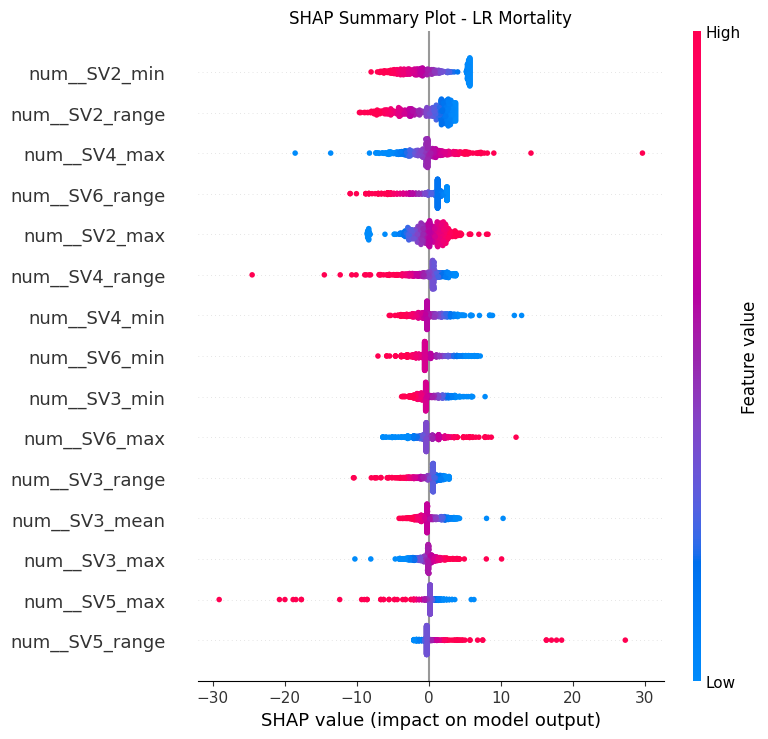

In [30]:
run_shap_analysis(best_lr, X_test, "LR Mortality")